# Numerical Simulation Laboratory - Exercise 11


**DISCLAIMER**: Running all cells in this notebook should take about 1 minute to 1 minute and 30 seconds. The most computationally expensive cells have already been executed, their results have been saved to file, and the corresponding code has been commented out. Avoid uncommenting those cells unless the full computations are actually needed: without the saved results, running the full notebook from scratch could take up to two hours. Since neural-network training is partly stochastic, rerunning the full computations may also produce slightly different numerical values from those reported in the comments. These values should remain consistent with the same qualitative conclusions.

## INTRODUCTION


#### The Prediction Problem

Consider a probabilistic process that gives rise to labeled data $(x,y)$. The data is generated by drawing samples from the equation

$$
 y_i= f(x_i) + \eta_i,
$$

where $f(x_i)$ is some fixed, but (possibly unknown) function, and $\eta_i$ is a Gaussian, uncorrelated noise variable such that

$$
\langle \eta_i \rangle=0 \\
\langle \eta_i \eta_j \rangle = \delta_{ij} \sigma
$$

The quantities $f(x_i)$ are referred to as the **true features** used to generate the data.

To make predictions, a NN depending on its parameters, weights and biases is considered. The functions that the NN can model represent the **model class** used to model the data and make predictions.

To learn the parameters of the NN, the models are trained on a **training data set** and then tested on a *different* dataset, the **validation data set**. The data must be divided into training and validation sets because the goal of machine learning is to make accurate predictions on new, previously unseen data.

To measure predictive ability, the parameters are learned by fitting the training dataset and then making predictions on the test data set. One common measure of predictive performance is obtained by comparing the predictions, $\{y_j^\mathrm{pred}\}$, with the true values $\{y_j\}$.

### Feed-forward neural networks and regression


A feed-forward neural network (FFNN) is a model that maps an input vector $x \in \mathbb{R}^p$ to an output through a sequence of layers. The information flows only in one direction, from the input layer to the output layer. In a fully connected, or dense, layer every neuron receives as input all the activations produced by the previous layer. If $h^{(0)}=x$, the $l$-th layer computes

$$
z^{(l)} = W^{(l)} h^{(l-1)} + b^{(l)},
\qquad
h^{(l)} = g^{(l)}\left(z^{(l)}\right),
$$

where $W^{(l)}$ is the weight matrix, $b^{(l)}$ is the bias vector, $z^{(l)}$ are the pre-activation values, and $g^{(l)}$ is the activation function. The trainable parameters of the network are therefore the weights and biases of all layers,

$$
\theta = \{W^{(l)}, b^{(l)}\}_{l=1}^{L}.
$$

The activation function is the ingredient that makes the network non-linear. If all activations were linear, the composition of many layers would still be only a single affine transformation of the input. In that case, adding hidden layers would not increase the class of functions that the model can represent. Non-linear activations such as ReLU, sigmoid, or hyperbolic tangent allow FFNNs to build non-linear combinations of the input variables. This is why neural networks can approximate complicated functions, while a purely linear model cannot.

In this laboratory the output is continuous, so the problem is a regression problem. For this reason the final layer usually contains one neuron with linear activation, and the network returns directly the predicted value $\hat{y}$. The quality of the prediction is measured through a loss function. A common choice, used in this notebook, is the mean squared error,

$$
\mathrm{MSE}=\frac{1}{N}\sum_{i=1}^{N}\left(y_i-\hat{y}_i\right)^2.
$$

Training consists in finding the parameters $\theta$ that minimize the loss on the training set. This is done through backpropagation, which applies the chain rule to compute the gradient of the loss with respect to each parameter. The parameters are then updated by an optimizer. In stochastic gradient descent (SGD), for example, the update has the form

$$
W \leftarrow W - \eta\,\frac{\partial \mathcal{L}}{\partial W},
\qquad
b \leftarrow b - \eta\,\frac{\partial \mathcal{L}}{\partial b},
$$

where $\eta$ is the learning rate. In practice the gradients are usually estimated on mini-batches, i.e. small random subsets of the training set, rather than on the whole dataset at every update. Other optimizers, such as Adam, modify this basic idea by adapting the effective step size during training.

Several hyperparameters control both the training dynamics and the expressive power of the model: the number of layers, the number of neurons per layer, the activation functions, the optimizer, the learning rate, the batch size, and the number of epochs. If the model is too simple, it may underfit the data and fail to reproduce the target function. If it is too flexible or trained for too long on noisy data, it may overfit, meaning that it learns features specific to the training sample instead of the underlying function. For this reason the training loss must be compared with the validation/test loss, which is computed on data not used to update the weights.

The main quantities monitored in the following sections are therefore the loss on the training set and the loss on an independent validation/test set. The training loss measures how well the model fits the data used for optimization, while the validation loss is more important for judging whether the model can generalize to unseen points. Since both the datasets and the neural-network initialization are random, the exact numerical values can change slightly from one run to another.


## EXERCISE 11.1


### Assignment prompt


In order to practice with neural networks, explore how the linear regression of the function

$$
f(x)=2x+1
$$

depends on the number of epochs $N_{\mathrm{epochs}}$, the number of training data points $N_{\mathrm{train}}$, and the noise level $\sigma$.

### Method


The target is the linear function $f(x)=2x+1$. Noisy data are generated by adding Gaussian noise with standard deviation $\sigma$, then split into a training set and a validation set. A **one-neuron neural network** is trained on these data.

### Data creation

In [146]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects
import matplotlib.pyplot as plt
import numpy as np
import os
import re

np.random.seed(0)
tf.random.set_seed(0)

m = 2
b = 1

sigma = 0.2

x_data = np.random.uniform(-1, 1, 550) 
y_data = np.random.normal(m * x_data + b, sigma)

x_train, x_test, y_train, y_test = train_test_split(
    x_data,
    y_data,
    test_size=0.1, 
    random_state=42,
    shuffle=True
)


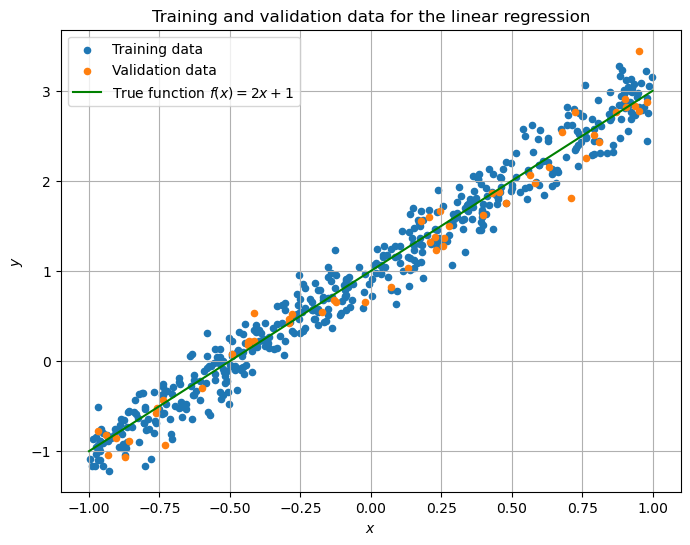

In [147]:
plt.figure(figsize=(8, 6))

x_line = np.linspace(-1, 1, 200)
y_line = m * x_line + b

plt.scatter(x_train, y_train, label='Training data', alpha=1,s=20)
plt.scatter(x_test, y_test, label='Validation data', alpha=1,s=20)
plt.plot(x_line, y_line, color='green', label=r'True function $f(x)=2x+1$')

plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('Training and validation data for the linear regression')
plt.legend()
plt.grid(True)
plt.show()

### Number of epochs


The first test changes only the number of epochs. For too few epochs, the optimizer has not yet converged, so both training and validation losses are still high. Once convergence is reached, increasing the number of epochs further gives only small or no improvements. In this simple one-neuron linear model, no clear overfitting is observed, because the model capacity is very limited and the validation loss follows the training loss.


In [148]:
model = tf.keras.Sequential()
model.add(Dense(1, input_shape=(1,))) # One layer with one neuron 

model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

history = model.fit(
    x=x_train,
    y=y_train,
    batch_size=32,
    epochs=200,
    shuffle=True,
    validation_data=(x_test, y_test),
    verbose=0
)

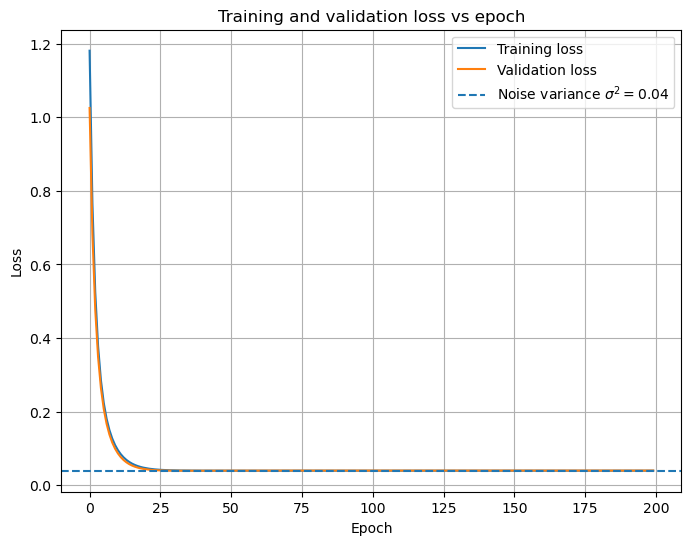

In [149]:
plt.figure(figsize=(8, 6))

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.axhline(y=0.04, linestyle='--', label=r'Noise variance $\sigma^2=0.04$')
plt.title('Training and validation loss vs epoch')
plt.legend()
plt.grid(True)
plt.show()

#### Comment


In this run, the loss decreases rapidly during the first epochs and reaches an approximately stable plateau. Since the loss function is the mean squared error, the natural reference scale set by the Gaussian noise is the variance $\sigma^2$, not the standard deviation $\sigma$. For $\sigma=0.2$, this corresponds to $\sigma^2=0.04$, which is consistent with the observed plateau. The validation loss does not show a systematic increase at large epoch numbers, so in this simple linear case there is no clear sign of overfitting in the explored range. This is also expected because the model consists of only one neuron and therefore has a very limited capacity: it can represent a linear function, but it is not flexible enough to strongly overfit the training data.

#### Optimized number of epochs: Early stopping


Early stopping is a practical way to avoid choosing the number of epochs by hand. The training is allowed to continue for many epochs, but it is stopped when the validation loss no longer improves for a fixed patience window. The best weights, according to the validation loss, are then restored.

In this analysis, the early-stopping procedure is repeated over 100 independent runs. For each run, the best epoch is identified as the epoch where the validation loss reaches its minimum. The final value of `best_epoch`, used in the following tests on $N_{\mathrm{train}}$ and $\sigma$, is obtained by averaging these best epochs and rounding the result to the nearest integer. The fitted weight and bias are also saved for each run, so that their average values can be compared with the expected parameters of the target function, $m=2$ and $b=1$.

In [150]:
# import csv

# n_runs = 100
# max_epochs = 1000 #troppe: serve solo ad essere scuro di non fermarci prima di aver raggiunto il minimo della curva di validazione
# patience = 10

# results_file = "Analysis_results/Exercise_11.1_best_epoch_runs.csv"

# results = []

# for run in range(n_runs):
    
#     seed = 3000 + run #different seed for each run to get a more general result
    
#     np.random.seed(seed)
#     tf.random.set_seed(seed)
#     tf.keras.backend.clear_session()
    
#     x_data = np.random.uniform(-1, 1, 550)
#     y_data = np.random.normal(m * x_data + b, sigma)
    
#     x_train, x_test, y_train, y_test = train_test_split(
#         x_data,
#         y_data,
#         test_size=0.1,
#         random_state=seed,
#         shuffle=True
#     )
    
#     model = tf.keras.Sequential()
#     model.add(Dense(1, input_shape=(1,)))

#     model.compile(
#         optimizer='sgd',
#         loss='mse',
#         metrics=['mse']
#     )

#     early_stop = tf.keras.callbacks.EarlyStopping(
#         monitor='val_loss',
#         restore_best_weights=True,
#         patience=patience
#     )

#     history = model.fit(
#         x=x_train,
#         y=y_train,
#         batch_size=32,
#         epochs=max_epochs,
#         shuffle=True,
#         validation_data=(x_test, y_test),
#         callbacks=[early_stop],
#         verbose=0
#     )
    
#     best_epoch_run = np.argmin(history.history['val_loss']) + 1
#     stopped_epoch_run = len(history.history['val_loss'])
#     best_val_loss_run = np.min(history.history['val_loss'])
#     best_train_loss_run = history.history['loss'][best_epoch_run - 1]
    
#     weights = model.get_weights()
#     fitted_weight = weights[0][0][0]
#     fitted_bias = weights[1][0]

#     results.append({
#         "run": run + 1,
#         "best_epoch": best_epoch_run,
#         "stopped_epoch": stopped_epoch_run,
#         "best_train_loss": best_train_loss_run,
#         "best_val_loss": best_val_loss_run,
#         "fitted_weight": fitted_weight,
#         "fitted_bias": fitted_bias
#     })

#     print(
#         f"Run {run + 1}: "
#         f"best epoch = {best_epoch_run}, "
#         f"stopped epoch = {stopped_epoch_run}, "
#         f"best validation loss = {best_val_loss_run:.6f}, "
#         f"weight = {fitted_weight:.6f}, "
#         f"bias = {fitted_bias:.6f}"
#     )

# with open(results_file, "w", newline="") as file:
#     writer = csv.DictWriter(
#         file,
#         fieldnames=[
#             "run",
#             "best_epoch",
#             "stopped_epoch",
#             "best_train_loss",
#             "best_val_loss",
#             "fitted_weight",
#             "fitted_bias"
#         ]
#     )
#     writer.writeheader()
#     writer.writerows(results)

# best_epochs = np.array([row["best_epoch"] for row in results])
# best_epoch = int(np.round(np.mean(best_epochs)))

# print(f"\nResults saved to {results_file}")


In [151]:
import pandas as pd

results_file = "Analysis_results/Exercise_11.1_best_epoch_runs.csv"

df_best_epoch = pd.read_csv(results_file)

mean_best_epoch = df_best_epoch["best_epoch"].mean()
best_epoch = int(round(mean_best_epoch))

mean_weight = df_best_epoch["fitted_weight"].mean()
mean_bias = df_best_epoch["fitted_bias"].mean()

print(f"Mean best epoch over 100 runs: {mean_best_epoch:.2f}")
print(f"Rounded best_epoch used later: {best_epoch}")

print("\nMean fitted parameters over 100 runs:")
print(f"Mean fitted weight: {mean_weight:.6f}")
print(f"Mean fitted bias: {mean_bias:.6f}")

print("\nExpected parameters:")
print("Expected weight: 2")
print("Expected bias: 1")

print("\nResults from the 100 runs:")
print(df_best_epoch[["run", "best_epoch", "best_val_loss", "fitted_weight", "fitted_bias"]])

Mean best epoch over 100 runs: 83.08
Rounded best_epoch used later: 83

Mean fitted parameters over 100 runs:
Mean fitted weight: 1.979815
Mean fitted bias: 0.999013

Expected parameters:
Expected weight: 2
Expected bias: 1

Results from the 100 runs:
    run  best_epoch  best_val_loss  fitted_weight  fitted_bias
0     1         144       0.053685       1.995731     1.000628
1     2         138       0.043381       2.014991     0.992394
2     3          33       0.041990       1.989408     1.007757
3     4          50       0.041264       1.982820     0.998100
4     5          42       0.043377       1.983237     0.984107
..  ...         ...            ...            ...          ...
95   96          45       0.040923       2.004122     1.017540
96   97         151       0.036847       1.982902     0.982410
97   98          44       0.032866       1.978656     1.008219
98   99          42       0.046287       1.985479     0.984995
99  100         118       0.050917       1.987154     1

#### Comment


The fitted slope and intercept are averaged over the 100 independent early-stopping runs and are close to the expected values $m=2$ and $b=1$. Since the model contains only one neuron, these two fitted parameters correspond directly to the slope and intercept of the learned linear function. Small deviations from the exact values are expected because the training data contain Gaussian noise and each run starts from a different random initialization.

The same set of runs is also used to estimate a representative number of epochs. For each run, the best epoch is identified from the minimum of the validation loss; these values are then averaged and rounded to obtain `best_epoch`. This value is used in the following tests, so that the comparisons with different $N_{\mathrm{train}}$ and $\sigma$ are not based on an arbitrary manually chosen number of epochs.

### Number of data points


The second test fixes the number of epochs to the value obtained from the previous loss-curve analysis and changes the size of the training set. For each value of $N_{\mathrm{train}}$, ten independent training runs are performed and saved to file; the plotted losses are then obtained by averaging these runs. This procedure is used because, with a single run for each dataset size, the results were too strongly affected by random fluctuations, making it difficult to isolate the actual effect of $N_{\mathrm{train}}$ on the quality of the fit. Averaging over independent runs reduces the effect of statistical fluctuations due to the random training samples, the random initialization of the network weights, and the stochastic optimization procedure. With very few data points, the model is more sensitive to the particular noisy sample, while larger datasets provide a more stable estimate of the underlying linear law.

It should be noted that the optimal number of epochs may in principle depend on the size of the training set: smaller and larger datasets can have different convergence times. In this simplified analysis, however, `best_epoch` is kept fixed in order to isolate the effect of $N_{\mathrm{train}}$ and to avoid performing a separate early-stopping study for each dataset size, which would significantly increase the computational cost.

In [152]:
# import csv

# N_train_to_test = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
# n_runs = 10

# results_file = "Analysis_results/Exercise_11.1_Ntrain_runs.csv"

# # Fixed validation set used for all runs
# rng_val = np.random.default_rng(123)
# x_val = rng_val.uniform(-1, 1, 50)
# y_val = rng_val.normal(m * x_val + b, sigma)

# results = []

# for N_train in N_train_to_test:
#     for run in range(n_runs):
        
#         seed = 1000 + 100 * N_train + run
        
#         rng = np.random.default_rng(seed)
#         x_data = rng.uniform(-1, 1, N_train)
#         y_data = rng.normal(m * x_data + b, sigma)
        
#         tf.keras.backend.clear_session()
#         tf.random.set_seed(seed)
        
#         model = tf.keras.Sequential()
#         model.add(Dense(1, input_shape=(1,)))

#         model.compile(
#             optimizer='sgd',
#             loss='mse',
#             metrics=['mse']
#         )

#         history = model.fit(
#             x=x_data,
#             y=y_data,
#             batch_size=32,
#             epochs=best_epoch,
#             shuffle=True,
#             validation_data=(x_val, y_val),
#             verbose=0
#         )

#         final_train_loss = history.history['loss'][-1]
#         final_val_loss = history.history['val_loss'][-1]

#         results.append({
#             "N_train": N_train,
#             "run": run + 1,
#             "epochs": best_epoch,
#             "train_loss": final_train_loss,
#             "val_loss": final_val_loss
#         })

#         print(
#             f"N_train: {N_train}, run: {run + 1}, "
#             f"Final training loss: {final_train_loss}, "
#             f"Final validation loss: {final_val_loss}"
#         )

# with open(results_file, "w", newline="") as file:
#     writer = csv.DictWriter(
#         file,
#         fieldnames=["N_train", "run", "epochs", "train_loss", "val_loss"]
#     )
#     writer.writeheader()
#     writer.writerows(results)

# print(f"\nResults saved to {results_file}")

# mean_train_losses = []
# std_train_losses = []
# mean_val_losses = []
# std_val_losses = []

# for N_train in N_train_to_test:
#     selected = [row for row in results if row["N_train"] == N_train]
    
#     train_values = np.array([row["train_loss"] for row in selected])
#     val_values = np.array([row["val_loss"] for row in selected])
    
#     mean_train_losses.append(np.mean(train_values))
#     std_train_losses.append(np.std(train_values))
#     mean_val_losses.append(np.mean(val_values))
#     std_val_losses.append(np.std(val_values))

# train_losses = mean_train_losses
# val_losses = mean_val_losses

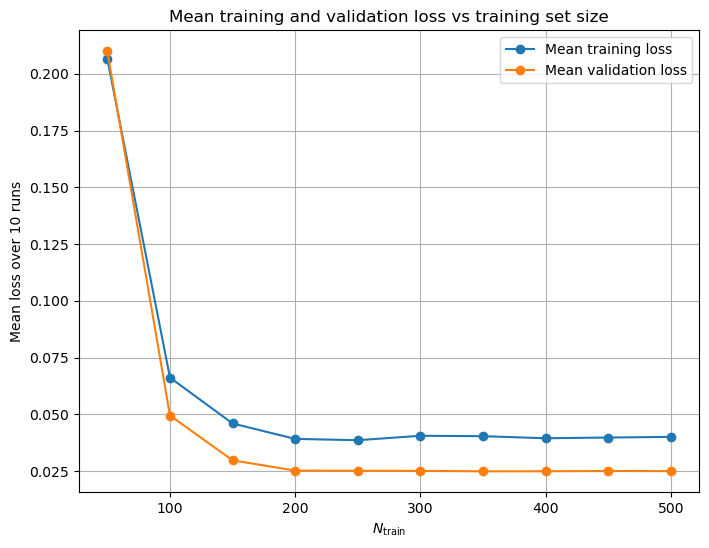

In [153]:
import pandas as pd

results_file = "Analysis_results/Exercise_11.1_Ntrain_runs.csv"

df_Ntrain = pd.read_csv(results_file)

mean_results = df_Ntrain.groupby("N_train", as_index=False)[["train_loss", "val_loss"]].mean()

plt.figure(figsize=(8, 6))

plt.plot(
    mean_results["N_train"],
    mean_results["train_loss"],
    marker='o',
    label='Mean training loss'
)

plt.plot(
    mean_results["N_train"],
    mean_results["val_loss"],
    marker='o',
    label='Mean validation loss'
)


plt.xlabel(r'$N_{\mathrm{train}}$')
plt.ylabel('Mean loss over 10 runs')
plt.title('Mean training and validation loss vs training set size')
plt.legend()
plt.grid(True)
plt.show()

#### Comment


In this averaged test, the validation loss decreases as the number of training points increases and becomes more stable for larger datasets. This behaviour is expected on average: with more training data, the model is less affected by the statistical fluctuations of a single noisy sample and can estimate the underlying linear law more reliably. Since each point is obtained by averaging ten independent runs, the effect of random initialization, noisy data generation, and stochastic optimization is reduced.

The validation loss is slightly smaller than the training loss for large training sets. This is not problematic in this case: the training and validation sets are different finite noisy samples, and the fixed validation set can have an empirical noise variance smaller than the training samples. Since the model has only one neuron, it is not flexible enough to overfit the training noise strongly; therefore the training loss is not necessarily smaller than the validation loss.

### Noise level


The last test changes the noise amplitude $\sigma$. For each value of $\sigma$, **ten** independent training runs are performed; the plotted losses are then obtained by averaging these runs. Even with the correct model, noisy labels introduce an irreducible contribution to the MSE: the network can learn only the deterministic linear trend, not the random noise term $\eta_i$. Since the loss is the mean squared error, the expected scale of this irreducible contribution grows approximately as $\sigma^2$.

As in the previous test on $N_{\mathrm{train}}$, the value of `best_epoch` is kept fixed for all noise levels. In principle, the optimal number of epochs could depend on $\sigma$, because noisier datasets can make the validation loss more irregular and can change the apparent convergence behaviour. However, in this simplified analysis, the same number of epochs is used for all values of $\sigma$ in order to isolate the effect of the noise amplitude and avoid performing a separate early-stopping study for each case.

In [154]:
# import csv

# sigma_to_test = np.linspace(2.0, 0.0, 11)
# n_runs = 10

# results_file = "Analysis_results/Exercise_11.1_sigma_runs.csv"

# results = []

# for sigma_value in sigma_to_test:
#     for run in range(n_runs):

#         seed = 2000 + int(round(sigma_value * 1000)) + run

#         rng = np.random.default_rng(seed)

#         x_data = rng.uniform(-1, 1, 100)
#         y_data = rng.normal(m * x_data + b, sigma_value)

#         x_val = rng.uniform(-1, 1, 50)
#         y_val = rng.normal(m * x_val + b, sigma_value)

#         tf.keras.backend.clear_session()
#         tf.random.set_seed(seed)

#         model = tf.keras.Sequential()
#         model.add(Dense(1, input_shape=(1,)))

#         model.compile(
#             optimizer='sgd',
#             loss='mse',
#             metrics=['mse']
#         )

#         history = model.fit(
#             x=x_data,
#             y=y_data,
#             batch_size=32,
#             epochs=best_epoch,
#             shuffle=True,
#             validation_data=(x_val, y_val),
#             verbose=0
#         )

#         final_train_loss = history.history['loss'][-1]
#         final_val_loss = history.history['val_loss'][-1]

#         results.append({
#             "sigma": sigma_value,
#             "run": run + 1,
#             "epochs": best_epoch,
#             "train_loss": final_train_loss,
#             "val_loss": final_val_loss
#         })

#         print(
#             f"Sigma: {sigma_value:.1f}, run: {run + 1}, "
#             f"Final training loss: {final_train_loss}, "
#             f"Final validation loss: {final_val_loss}"
#         )

# with open(results_file, "w", newline="") as file:
#     writer = csv.DictWriter(
#         file,
#         fieldnames=["sigma", "run", "epochs", "train_loss", "val_loss"]
#     )
#     writer.writeheader()
#     writer.writerows(results)

# print(f"\nResults saved to {results_file}")

# train_losses = []
# val_losses = []

# for sigma_value in sigma_to_test:
#     selected = [
#         row for row in results
#         if np.isclose(row["sigma"], sigma_value)
#     ]

#     train_values = np.array([row["train_loss"] for row in selected])
#     val_values = np.array([row["val_loss"] for row in selected])

#     train_losses.append(np.mean(train_values))
#     val_losses.append(np.mean(val_values))

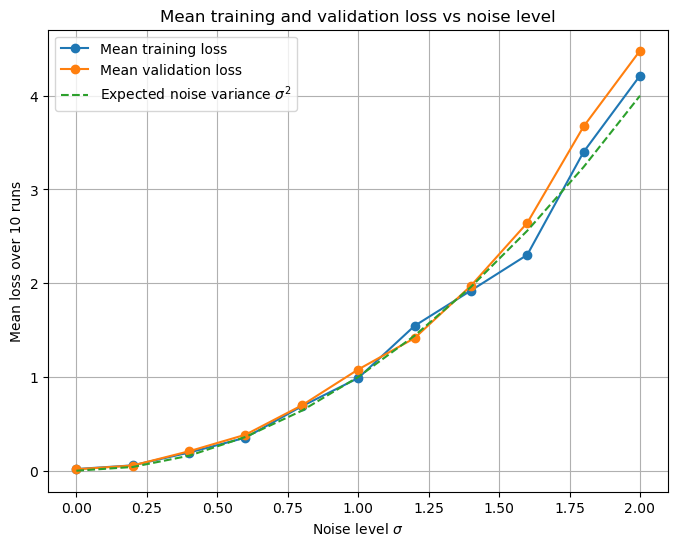

In [155]:
import pandas as pd

results_file = "Analysis_results/Exercise_11.1_sigma_runs.csv"

df_sigma = pd.read_csv(results_file)

mean_results = (
    df_sigma
    .groupby("sigma", as_index=False)[["train_loss", "val_loss"]]
    .mean()
    .sort_values("sigma")
)

plt.figure(figsize=(8, 6))

plt.plot(
    mean_results["sigma"],
    mean_results["train_loss"],
    marker='o',
    label='Mean training loss'
)

plt.plot(
    mean_results["sigma"],
    mean_results["val_loss"],
    marker='o',
    label='Mean validation loss'
)

plt.plot(
    mean_results["sigma"],
    mean_results["sigma"]**2,
    linestyle='--',
    label=r'Expected noise variance $\sigma^2$'
)

plt.xlabel(r'Noise level $\sigma$')
plt.ylabel('Mean loss over 10 runs')
plt.title('Mean training and validation loss vs noise level')
plt.legend()
plt.grid(True)
plt.show()

#### Comment


As expected, smaller values of $\sigma$ lead to lower training and validation losses. Since the loss is the mean squared error, the losses follow the same qualitative behaviour as the reference curve $\sigma^2$: larger noise produces a larger irreducible error. For large values of $\sigma$, the target line is still present on average, but the individual labels are much more scattered and the network cannot predict the random component of the noise. The case $\sigma=0$ is the easiest one: the data lie exactly on the line and the final loss can become very small.

## EXERCISE 11.2


### Assignment prompt


Try to extend the model to obtain a reasonable fit of the following polynomial of order 3:

$$
f(x)=4-3x-2x^2+3x^3
$$
for $x \in [-1,1]$.

Find good (& reasonable) choices for:

- the number of layers
- the number of neurons in each layer
- the activation function
- the optimizer
- the loss function
  
Check your NN model by seeing how well your fits predict newly generated test data (including on data outside the range you fit. How well do your NN do on points in the range of $x$ where you trained the model? How about points outside the original training data set? 
Summarize what you have learned about the relationship between model complexity (number of parameters), goodness of fit on training data, and the ability to predict well.


### Method


The target function is now nonlinear, therefore a single linear neuron is not sufficient. Noisy data are generated in the interval $[-1,1]$ and a **grid search** is developed over different architectures and training choices. The selected model is then tested both inside the training range and on the wider interval $[-2,2]$.


In [156]:
def f_poly(x):
    return 4 - 3*x - 2*x**2 + 3*x**3

sigma = 0.1

x_data = np.random.uniform(-1, 1, 1000)
y_data = np.random.normal(f_poly(x_data), sigma)

x_train, x_test, y_train, y_test = train_test_split(
    x_data,
    y_data,
    test_size=0.1, # Same proportion of training and validation data as in the linear case
    shuffle=True
)


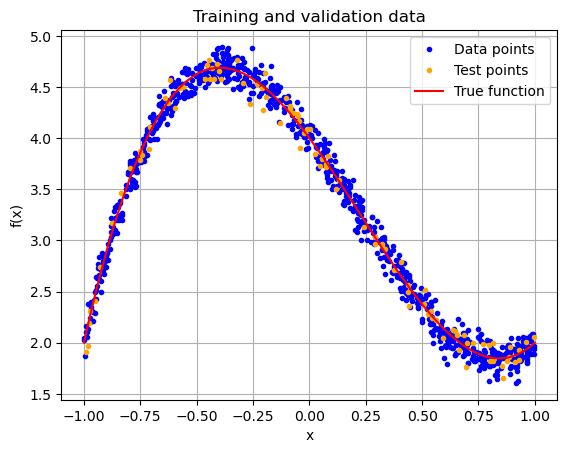

In [157]:
x_plot = np.linspace(-1, 1, 400)
y_plot = f_poly(x_plot)

plt.plot(x_train, y_train, 'o', label='Data points', color='blue', markersize=3)
plt.plot(x_test, y_test, 'o', label='Test points', color='orange', markersize=3)
plt.plot(x_plot, y_plot, label='True function', color='red')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Training and validation data')
plt.legend()
plt.grid(True)
plt.show()


### Grid search setup


The grid search explores different losses, activation functions, optimizers, numbers of neurons and numbers of hidden layers. The long grid-search cell is kept commented because the search has already been performed and saved in `Exercise_11.2_grid_search.txt`. The code below reads this file and selects the configuration with the smallest validation MSE among the valid runs.


The number of epochs is not varied in this grid search: it is fixed to 100 for all configurations. This choice keeps the computational cost manageable and allows the comparison to focus on the architecture, activation function, optimizer and loss function. A more complete search could also include the number of epochs, or use early stopping separately for each configuration, but this would make the grid search significantly more expensive.

The optimizer is varied by using the Keras string identifiers `'sgd'`, `'rmsprop'` and `'adam'`. In this way, each optimizer is tested with its default internal hyperparameters, such as the learning rate and, when present, momentum or adaptive-moment parameters. Therefore, the grid search compares the standard default versions of these optimizers, without performing an additional tuning of their internal parameters.

In [158]:
import os
import re

The tested parameter values are:

In [159]:
loss_list = ['mse', 'mae']
metrics_list = ['mse']
epochs_list = [100]
activation_list = ['relu', 'linear', 'tanh', 'sigmoid']
optimizer_list = ['sgd', 'rmsprop', 'adam']
number_of_neurons_list = [5, 10, 20]
number_of_layers_list = [1, 2, 3]


In [160]:
# combination_id = 0

# best_val_metric = np.inf
# best_config = None

# results = []

# last_completed_id = 0

# if os.path.exists("Analysis_results/Exercise_11.2_grid_search.txt"):
#     with open("Analysis_results/Exercise_11.2_grid_search.txt", "r") as file:
#         content = file.read()
#         completed_ids = re.findall(r"Combination ID=(\d+):.*(?:Final validation metric=|FAILED:)", content)
#         if len(completed_ids) > 0:
#             last_completed_id = max([int(i) for i in completed_ids])

# print(f"Restarting from Combination ID={last_completed_id + 1}")

# with open("Analysis_results/Exercise_11.2_grid_search.txt", "a") as file:
#     file.write("\n\nNew grid search run:\n")

#     for loss in loss_list:
#         for metric in metrics_list:
#             for epoch in epochs_list:
#                 for activation in activation_list:
#                     for optimizer in optimizer_list:
#                         for neurons in number_of_neurons_list:
#                             for layers in number_of_layers_list:
#                                 combination_id += 1

#                                 if combination_id <= last_completed_id:
#                                     continue

#                                 print(f"Testing configuration: Combination ID={combination_id}, Loss={loss}, Metric={metric}, Epochs={epoch}, Activation={activation}, Optimizer={optimizer}, Neurons={neurons}, Layers={layers}")

#                                 # Create a new model for each configuration
#                                 model = tf.keras.Sequential()

#                                 model.add(Dense(neurons, input_shape=(1,), activation=activation))

#                                 for _ in range(layers - 1):
#                                     model.add(Dense(neurons, activation=activation))

#                                 model.add(Dense(1))

#                                 try:
#                                     model.compile(optimizer=optimizer,loss=loss,metrics=[metric])

#                                     history = model.fit(x=x_train,y=y_train,batch_size=32,epochs=epoch,shuffle=True,validation_data=(x_test, y_test),verbose=0)

#                                     final_train_loss = history.history['loss'][-1]
#                                     final_val_loss = history.history['val_loss'][-1]
#                                     final_train_metric = history.history[metric][-1]
#                                     final_val_metric = history.history["val_" + metric][-1]
#                                     n_parameters = model.count_params()

#                                     line = f"Combination ID={combination_id}: Loss={loss}, Metric={metric}, Epochs={epoch}, Activation={activation}, Optimizer={optimizer}, Neurons={neurons}, Layers={layers}, Final training loss={final_train_loss}, Final validation loss={final_val_loss}, Final training metric={final_train_metric}, Final validation metric={final_val_metric}, Number of parameters={n_parameters}\n"

#                                     print(line, end="")
#                                     file.write(line)
#                                     file.flush()

#                                     results.append({
#                                         "combination_id": combination_id,
#                                         "loss": loss,
#                                         "metric": metric,
#                                         "epochs": epoch,
#                                         "activation": activation,
#                                         "optimizer": optimizer,
#                                         "neurons": neurons,
#                                         "layers": layers,
#                                         "train_loss": final_train_loss,
#                                         "val_loss": final_val_loss,
#                                         "train_metric": final_train_metric,
#                                         "val_metric": final_val_metric,
#                                         "n_parameters": n_parameters
#                                     })

#                                     if final_val_metric < best_val_metric:
#                                         best_val_metric = final_val_metric
#                                         best_config = results[-1]

#                                 except Exception as e:
#                                     line = f"Combination ID={combination_id}: Loss={loss}, Metric={metric}, Epochs={epoch}, Activation={activation}, Optimizer={optimizer}, Neurons={neurons}, Layers={layers}, FAILED: {e}\n"
#                                     print(line, end="")
#                                     file.write(line)
#                                     file.flush()

#     file.write("\nBest configuration of this run:\n")
#     file.write(str(best_config))

### Best model selected from the grid search performance


In [161]:
filename = "Analysis_results/Exercise_11.2_grid_search.txt"

if not os.path.exists(filename):
    raise FileNotFoundError(
        f"{filename} not found. Keep this notebook in the same folder as the grid-search text file."
    )

best_val_metric = np.inf
best_config = None

with open(filename, "r") as file:
    lines = file.readlines()

for line in lines:
    match = re.search(
        r"Combination ID=(\d+): Loss=(.*?), Metric=(.*?), Epochs=(\d+), Activation=(.*?), Optimizer=(.*?), Neurons=(\d+), Layers=(\d+), Final training loss=(.*?), Final validation loss=(.*?), Final training metric=(.*?), Final validation metric=(.*?), Number of parameters=(\d+)",
        line
    )

    if match:
        combination_id = int(match.group(1))
        loss = match.group(2)
        metric = match.group(3)
        epochs = int(match.group(4))
        activation = match.group(5)
        optimizer = match.group(6)
        neurons = int(match.group(7))
        layers = int(match.group(8))
        train_loss = float(match.group(9))
        val_loss = float(match.group(10))
        train_metric = float(match.group(11))
        val_metric = float(match.group(12))
        n_parameters = int(match.group(13))

        if val_metric < best_val_metric:
            best_val_metric = val_metric
            best_config = {
                "combination_id": combination_id,
                "loss": loss,
                "metric": metric,
                "epochs": epochs,
                "activation": activation,
                "optimizer": optimizer,
                "neurons": neurons,
                "layers": layers,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "train_metric": train_metric,
                "val_metric": val_metric,
                "n_parameters": n_parameters
            }

if best_config is None:
    raise ValueError("No valid configuration with Final validation metric was found.")

print("Best configuration:")
print(best_config)

model = tf.keras.Sequential()
model.add(Dense(best_config["neurons"], input_shape=(1,), activation=best_config["activation"]))

for _ in range(best_config["layers"] - 1):
    model.add(Dense(best_config["neurons"], activation=best_config["activation"]))

model.add(Dense(1))

model.compile(
    optimizer=best_config["optimizer"],
    loss=best_config["loss"],
    metrics=[best_config["metric"]]
)

#model.summary()


Best configuration:
{'combination_id': 24, 'loss': 'mse', 'metric': 'mse', 'epochs': 100, 'activation': 'relu', 'optimizer': 'adam', 'neurons': 10, 'layers': 3, 'train_loss': 0.011167580261826515, 'val_loss': 0.01194027904421091, 'train_metric': 0.011167580261826515, 'val_metric': 0.01194027904421091, 'n_parameters': 251}


c:\Users\tomma\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


The best configuration saved in the grid-search file is a **ReLU** network trained with **Adam** and **MSE** loss. It has **three hidden layers**, **ten neurons** per hidden layer, and 251 trainable parameters. This is complex enough to reproduce the cubic curve inside the training interval, but still reasonably small.


In [162]:
history = model.fit(
    x=x_train,
    y=y_train,
    batch_size=32,
    epochs=best_config["epochs"],
    shuffle=True,
    validation_data=(x_test, y_test),
    verbose=0
)

metric_name = best_config["metric"]

final_train_metric = history.history[metric_name][-1]
final_val_metric = history.history[f"val_{metric_name}"][-1]

print()
print(f"Training {metric_name}:", final_train_metric)
print(f"Validation {metric_name}:", final_val_metric)


Training mse: 0.010278204455971718
Validation mse: 0.011666961945593357


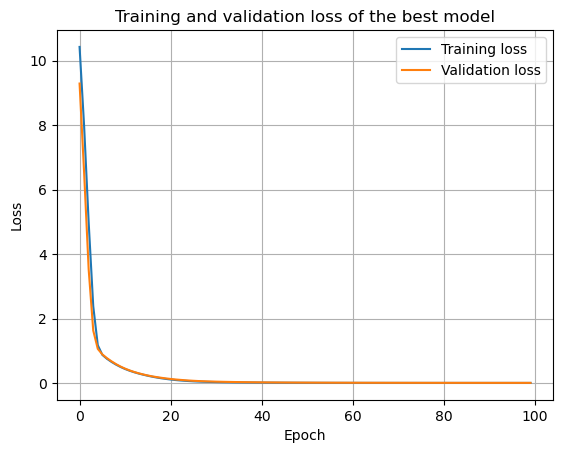

In [163]:
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and validation loss of the best model')
plt.legend()
plt.grid(True)
plt.show()


### Prediction inside the training range


MSE with respect to the exact function inside [-1,1]: 0.0013347969858057967


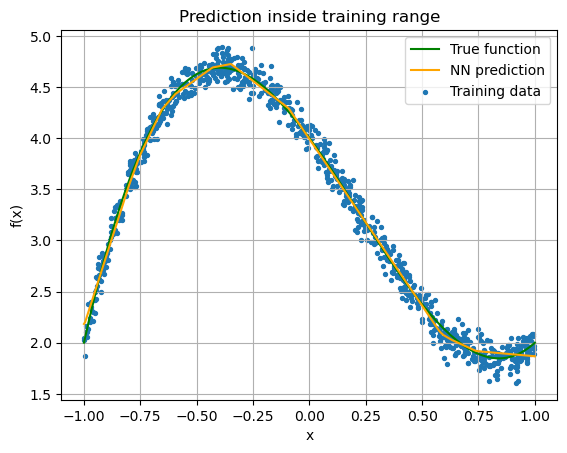

In [164]:
x_inside = np.linspace(-1, 1, 400)
y_inside_true = f_poly(x_inside)
y_inside_pred = model.predict(x_inside, verbose=0).flatten()

inside_mse = np.mean((y_inside_pred - y_inside_true)**2)

print("MSE with respect to the exact function inside [-1,1]:", inside_mse)

plt.plot(x_inside, y_inside_true, label='True function', color='green')
plt.plot(x_inside, y_inside_pred, label='NN prediction', color='orange')
plt.scatter(x_train, y_train, label='Training data', s=8)

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Prediction inside training range')
plt.legend()
plt.grid(True)
plt.show()


#### Comment


Inside the training interval $[-1,1]$, the neural-network prediction follows the cubic target well. The architecture selected through the grid search gives a good result, with a low validation loss and a prediction curve that remains close to the exact function in the region where training data are available.

### Prediction outside the training range


Grid MSE against the noiseless target inside [-1,1]: 0.0012999899950162214
Grid MSE against the noiseless target outside [-1,1]: 80.19722924811889


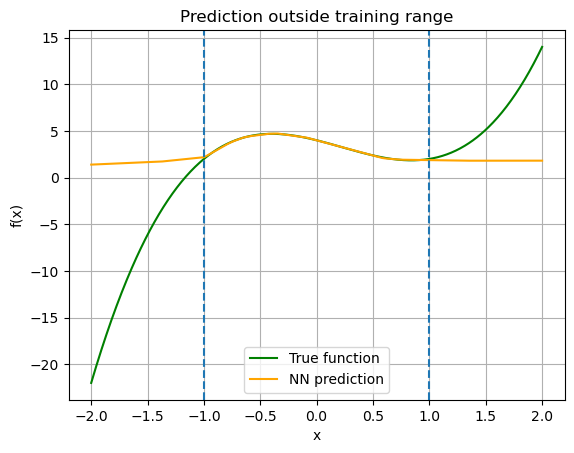

In [165]:
x_outside = np.linspace(-2, 2, 800)
y_outside_true = f_poly(x_outside)
y_outside_pred = model.predict(x_outside, verbose=0).flatten()

mask_inside = (x_outside >= -1) & (x_outside <= 1)
mask_outside = ~mask_inside

mse_inside = np.mean((y_outside_pred[mask_inside] - y_outside_true[mask_inside])**2)
mse_outside = np.mean((y_outside_pred[mask_outside] - y_outside_true[mask_outside])**2)

print("Grid MSE against the noiseless target inside [-1,1]:", mse_inside)
print("Grid MSE against the noiseless target outside [-1,1]:", mse_outside)

plt.plot(x_outside, y_outside_true, label='True function', color='green')
plt.plot(x_outside, y_outside_pred, label='NN prediction', color='orange')

plt.axvline(-1, linestyle='--')
plt.axvline(1, linestyle='--')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Prediction outside training range')
plt.legend()
plt.grid(True)
plt.show()


#### Comment


The behavior outside $[-1,1]$ is much worse. This is not surprising: the network has never seen data in this region, and the loss function does not penalize the behaviour of the extrapolated curve. In the displayed run the MSE inside the training interval is of order $10^{-3}$, while outside the interval it becomes very large. This is a clear example of the fact that a neural network can interpolate well but still extrapolate very poorly.


### Summary of the selected best model


In [166]:
print("Best model parameters:")
print("Number of hidden layers:", best_config["layers"])
print("Number of neurons per layer:", best_config["neurons"])
print("Activation function:", best_config["activation"])
print("Optimizer:", best_config["optimizer"])
print("Loss function:", best_config["loss"])
print("Validation metric:", best_config["metric"])
print("Number of trainable parameters:", best_config["n_parameters"])

Best model parameters:
Number of hidden layers: 3
Number of neurons per layer: 10
Activation function: relu
Optimizer: adam
Loss function: mse
Validation metric: mse
Number of trainable parameters: 251


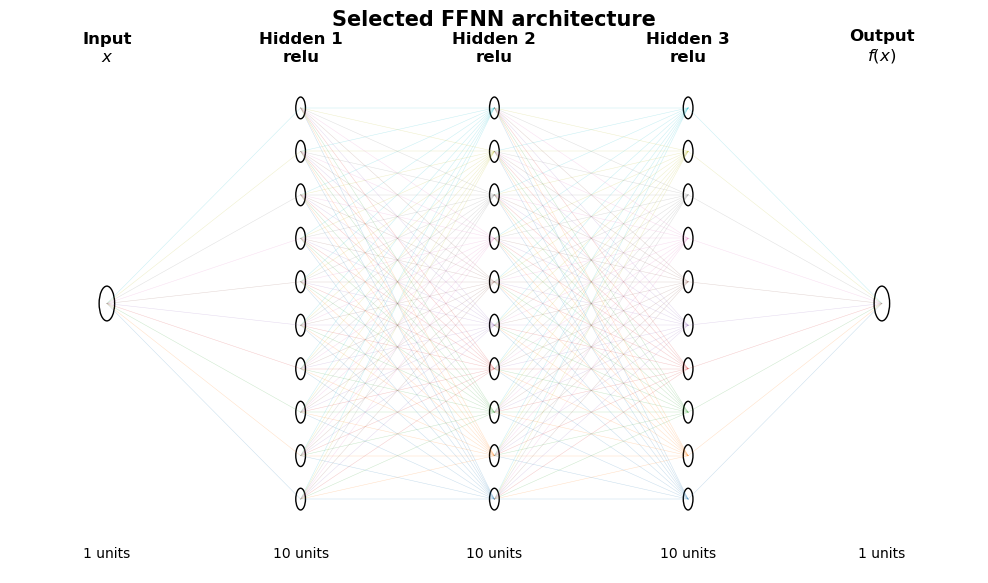

In [167]:
def draw_ffnn_architecture(best_config):
    n_hidden_layers = int(best_config["layers"])
    n_neurons = int(best_config["neurons"])

    layer_sizes = [1] + [n_neurons] * n_hidden_layers + [1]
    layer_labels = (
        ["Input\n$x$"] +
        [f"Hidden {i+1}\n{best_config['activation']}" for i in range(n_hidden_layers)] +
        ["Output\n$f(x)$"]
    )

    x_positions = np.arange(len(layer_sizes))
    fig, ax = plt.subplots(figsize=(2.5 * len(layer_sizes), 7))

    y_positions_all = []

    for x, n_nodes, label in zip(x_positions, layer_sizes, layer_labels):
        y_positions = np.array([0.5]) if n_nodes == 1 else np.linspace(0.05, 0.95, n_nodes)
        y_positions_all.append(y_positions)

        radius = 0.04 if n_nodes == 1 else 0.025

        for y in y_positions:
            ax.add_patch(plt.Circle((x, y), radius, fill=False, linewidth=1.0))

        ax.text(x, 1.05, label, ha="center", va="bottom", fontsize=12, fontweight="bold")
        ax.text(x, -0.06, f"{n_nodes} units", ha="center", va="top", fontsize=10)

    for i in range(len(layer_sizes) - 1):
        alpha = 0.08 if layer_sizes[i] * layer_sizes[i+1] > 1000 else 0.25
        linewidth = 0.15 if layer_sizes[i] * layer_sizes[i+1] > 1000 else 0.35

        for y1 in y_positions_all[i]:
            for y2 in y_positions_all[i+1]:
                ax.plot([x_positions[i], x_positions[i+1]], [y1, y2], alpha=alpha, linewidth=linewidth)

    ax.set_xlim(-0.5, len(layer_sizes) - 0.5)
    ax.set_ylim(-0.12, 1.12)
    ax.axis("off")

    plt.title("Selected FFNN architecture", fontsize=15, fontweight="bold")
    plt.show()


draw_ffnn_architecture(best_config)

Increasing the number of layers and neurons increases the number of trainable parameters and therefore increases the flexibility of the model. This usually makes it easier to reduce the training loss, especially for nonlinear target functions such as the cubic polynomial. However, a lower training loss is not sufficient to guarantee a better predictive model.

If the model is too simple, it may underfit: it cannot reproduce the structure of the target function and both training and validation losses remain high. If the model is too complex, it may instead overfit: it can start reproducing the noise or accidental features of the training sample, obtaining a low training loss but a worse validation loss. Therefore, the validation loss is the relevant quantity for selecting a model that predicts well on new data drawn from the same distribution.

The comparison between predictions inside and outside the training interval $[-1,1]$ shows another important point. A model can interpolate well where training data are available, but this does not imply reliable extrapolation outside that range. For this reason, a good model should have enough complexity to describe the target function, but not unnecessary complexity, and its performance should be judged mainly from validation data in the domain where predictions are required.

## EXERCISE 11.3


### Assignment prompt


Try to extend the model to fit a simple trigonometric 2D function such as $f(x,y) = \sin(x^2+y^2)$ in the range $x \in [-3/2,3/2]$ and $y \in [-3/2,3/2]$.


### Method


The input now has two coordinates, $(x,y)$, and the target is the nonlinear surface

$$
f(x,y)=\sin(x^2+y^2).
$$

This problem is more demanding than the one-dimensional polynomial fit because the network must approximate a two-dimensional surface. Noisy points are generated in the square $[-1.5,1.5]\times[-1.5,1.5]$, a **grid search** is again performed over feed-forward architectures, and the true and predicted surfaces are then compared inside the training square.


In [168]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [169]:
def f_2d(x, y):
    return np.sin(x**2 + y**2)

sigma = 0.1

x_data = np.random.uniform(-1.5, 1.5, 1000)
y_data = np.random.uniform(-1.5, 1.5, 1000)

z_data = np.random.normal(f_2d(x_data, y_data), sigma)

data = np.column_stack((x_data, y_data))

x_train, x_test, y_train, y_test = train_test_split(
    data,
    z_data,
    test_size=0.1,
    random_state=42,
    shuffle=True
)


### Training and validation data


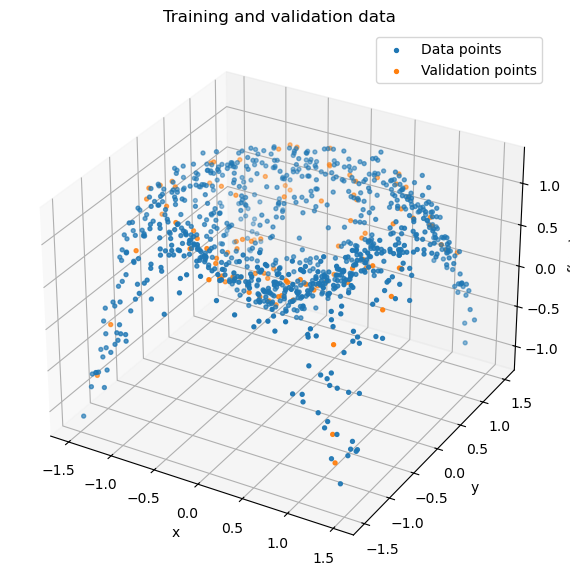

In [170]:
fig = plt.figure()
fig.set_size_inches(7, 7)
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x_train[:,0], x_train[:,1], y_train, label='Data points', s=8)
ax.scatter(x_test[:,0], x_test[:,1], y_test, label='Validation points', s=8)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')
ax.set_title('Training and validation data')
ax.legend()

plt.show()

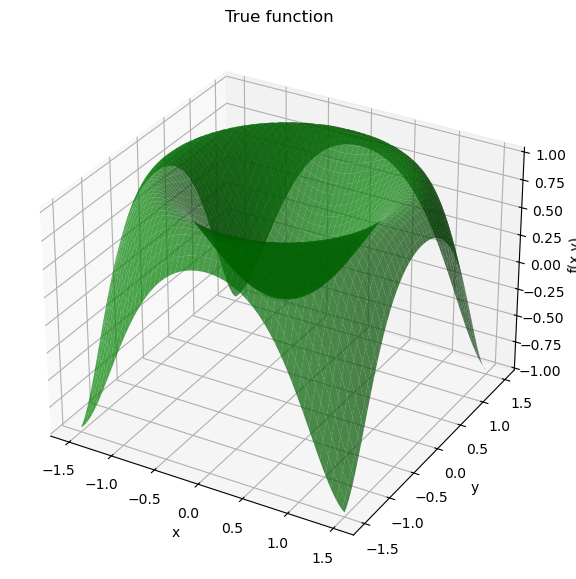

In [171]:
x_plot = np.linspace(-1.5, 1.5, 100)
y_plot = np.linspace(-1.5, 1.5, 100)

X_plot, Y_plot = np.meshgrid(x_plot, y_plot)
Z_plot = f_2d(X_plot, Y_plot)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X_plot, Y_plot, Z_plot, alpha=0.7, color='green', label='True function')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')
ax.set_title('True function')

plt.show()


### Exercise 11.2 architecture applied to the two-dimensional problem


Before performing the dedicated grid search for Exercise 11.3, the architecture selected in Exercise 11.2 is tested on the two-dimensional target function. The input layer is adapted from one coordinate to two coordinates, while the number of hidden layers, the number of neurons per layer, the activation function, the optimizer, the loss function and the number of epochs are kept from the best one-dimensional configuration. This provides a useful baseline to check whether the model selected for the cubic regression is also adequate for the two-dimensional surface.


In [172]:
best_config_11_2 = best_config.copy()

model_11_2_arch_2d = tf.keras.Sequential()
model_11_2_arch_2d.add(tf.keras.Input(shape=(2,)))

for _ in range(best_config_11_2["layers"]):
    model_11_2_arch_2d.add(
        Dense(
            best_config_11_2["neurons"],
            activation=best_config_11_2["activation"]
        )
    )

model_11_2_arch_2d.add(Dense(1))

model_11_2_arch_2d.compile(
    optimizer=best_config_11_2["optimizer"],
    loss=best_config_11_2["loss"],
    metrics=[best_config_11_2["metric"]]
)

history_11_2_arch_2d = model_11_2_arch_2d.fit(
    x=x_train,
    y=y_train,
    batch_size=32,
    epochs=best_config_11_2["epochs"],
    shuffle=True,
    validation_data=(x_test, y_test),
    verbose=0
)
metric_name_11_2_arch_2d = best_config_11_2["metric"]

train_metric_11_2_arch_2d = history_11_2_arch_2d.history[metric_name_11_2_arch_2d][-1]
val_metric_11_2_arch_2d = history_11_2_arch_2d.history[f"val_{metric_name_11_2_arch_2d}"][-1]

print("Exercise 11.2 architecture applied to Exercise 11.3")
print("Number of hidden layers:", best_config_11_2["layers"])
print("Number of neurons per layer:", best_config_11_2["neurons"])
print("Activation function:", best_config_11_2["activation"])
print("Optimizer:", best_config_11_2["optimizer"])
print("Loss function:", best_config_11_2["loss"])
print("Validation metric:", best_config_11_2["metric"])
print("Epochs:", best_config_11_2["epochs"])
print()
print(f"Training metric ({metric_name_11_2_arch_2d}):", train_metric_11_2_arch_2d)
print(f"Validation metric ({metric_name_11_2_arch_2d}):", val_metric_11_2_arch_2d)


Exercise 11.2 architecture applied to Exercise 11.3
Number of hidden layers: 3
Number of neurons per layer: 10
Activation function: relu
Optimizer: adam
Loss function: mse
Validation metric: mse
Epochs: 100

Training metric (mse): 0.012083521112799644
Validation metric (mse): 0.012230344116687775


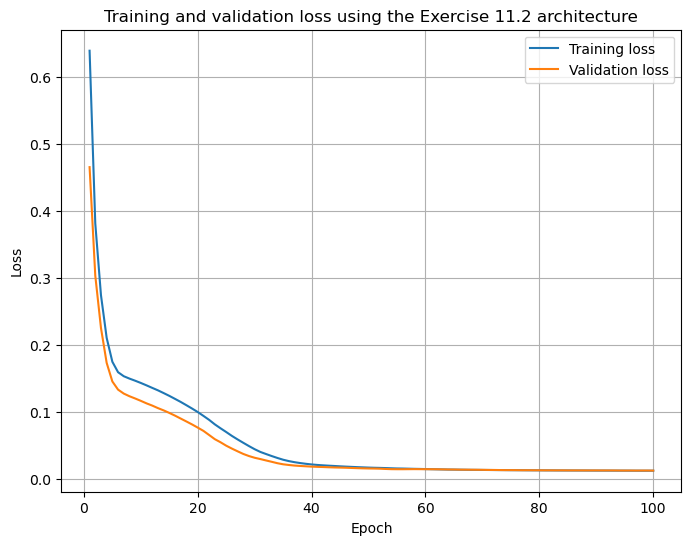

In [173]:
plt.figure(figsize=(8, 6))

epochs = np.arange(1, len(history_11_2_arch_2d.history["loss"]) + 1)

plt.plot(epochs, history_11_2_arch_2d.history["loss"], label="Training loss")
plt.plot(epochs, history_11_2_arch_2d.history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss using the Exercise 11.2 architecture")
plt.legend()
plt.grid(True)
plt.show()


#### Comment

The model selected in Exercise 11.2 gave training MSE $\simeq 0.0103$ and validation MSE $\simeq 0.0117$ on the cubic problem. When the same architecture is applied to the two-dimensional problem, the metrics become training MSE $\simeq 0.0121$ and validation MSE $\simeq 0.0122$. The performance is therefore only slightly worse, which is expected: the architecture was optimized for the simpler one-dimensional polynomial and is now used for the more difficult function $f(x,y)=\sin(x^2+y^2)$, which depends on two input variables.

The increase in the metric is limited, so the model still gives a good approximation of the new target function. The training and validation metrics are also close to each other, which means that no clear overfitting is observed. Overall, the result suggests that the problem is more complex than the cubic fit, but not dramatically harder for this architecture. A dedicated grid search for Exercise 11.3 is still useful to check whether a model optimized directly on the two-dimensional data can improve the prediction.

### Grid search setup


As in Exercise 11.2, the full grid search is kept commented and the saved results are read from `Exercise_11.3_grid_search.txt`. The validation metric used to choose the best model is MSE, so all configurations are compared using the same quantitative criterion.

The number of epochs is not varied in the grid search: it is fixed to the value used when the search was performed. This keeps the computational cost manageable and allows the comparison to focus on the architecture, activation function, optimizer and loss function. A more compleete search could also include the number of epochs, or use early stopping separately for each configuration, but this would make the grid search significantly more expensive.

The grid search tests the following parameter values:

In [174]:
loss_list = ['mse','mae']
metrics_list =['mse']
epochs_list = [100]
activation_list = ['relu', 'linear', 'tanh', 'sigmoid']
optimizer_list = ['sgd', 'rmsprop', 'adam']
number_of_neurons_list = [5, 10 , 20]
number_of_layers_list = [1, 2, 3]

In [175]:
# combination_id = 0

# best_val_metric = np.inf
# best_config = None

# results = []

# last_completed_id = 0

# if os.path.exists("Analysis_results/Exercise_11.3_grid_search.txt"):
#     with open("Analysis_results/Exercise_11.3_grid_search.txt", "r") as file:
#         content = file.read()
#         completed_ids = re.findall(r"Combination ID=(\d+):.*(?:Final validation metric=|FAILED:)", content)
#         if len(completed_ids) > 0:
#             last_completed_id = max([int(i) for i in completed_ids])

# print(f"Restarting from Combination ID={last_completed_id + 1}")

# with open("Analysis_results/Exercise_11.3_grid_search.txt", "a") as file:
#     file.write("\n\nNew grid search run:\n")

#     for loss in loss_list:
#         for metric in metrics_list:
#             for epoch in epochs_list:
#                 for activation in activation_list:
#                     for optimizer in optimizer_list:
#                         for neurons in number_of_neurons_list:
#                             for layers in number_of_layers_list:
#                                 combination_id += 1

#                                 if combination_id <= last_completed_id:
#                                     continue

#                                 print(f"Testing configuration: Combination ID={combination_id}, Loss={loss}, Metric={metric}, Epochs={epoch}, Activation={activation}, Optimizer={optimizer}, Neurons={neurons}, Layers={layers}")

#                                 # Create a new model for each configuration
#                                 model = tf.keras.Sequential()

#                                 model.add(Dense(neurons, input_shape=(2,), activation=activation))

#                                 for _ in range(layers - 1):
#                                     model.add(Dense(neurons, activation=activation))

#                                 model.add(Dense(1))

#                                 try:
#                                     model.compile(optimizer=optimizer,loss=loss,metrics=[metric])

#                                     history = model.fit(x=x_train,y=y_train,batch_size=32,epochs=epoch,shuffle=True,validation_data=(x_test, y_test),verbose=0)

#                                     final_train_loss = history.history['loss'][-1]
#                                     final_val_loss = history.history['val_loss'][-1]
#                                     final_train_metric = history.history[metric][-1]
#                                     final_val_metric = history.history["val_" + metric][-1]
#                                     n_parameters = model.count_params()

#                                     line = f"Combination ID={combination_id}: Loss={loss}, Metric={metric}, Epochs={epoch}, Activation={activation}, Optimizer={optimizer}, Neurons={neurons}, Layers={layers}, Final training loss={final_train_loss}, Final validation loss={final_val_loss}, Final training metric={final_train_metric}, Final validation metric={final_val_metric}, Number of parameters={n_parameters}\n"

#                                     print(line, end="")
#                                     file.write(line)
#                                     file.flush()

#                                     results.append({
#                                         "combination_id": combination_id,
#                                         "loss": loss,
#                                         "metric": metric,
#                                         "epochs": epoch,
#                                         "activation": activation,
#                                         "optimizer": optimizer,
#                                         "neurons": neurons,
#                                         "layers": layers,
#                                         "train_loss": final_train_loss,
#                                         "val_loss": final_val_loss,
#                                         "train_metric": final_train_metric,
#                                         "val_metric": final_val_metric,
#                                         "n_parameters": n_parameters
#                                     })

#                                     if final_val_metric < best_val_metric:
#                                         best_val_metric = final_val_metric
#                                         best_config = results[-1]

#                                 except Exception as e:
#                                     line = f"Combination ID={combination_id}: Loss={loss}, Metric={metric}, Epochs={epoch}, Activation={activation}, Optimizer={optimizer}, Neurons={neurons}, Layers={layers}, FAILED: {e}\n"
#                                     print(line, end="")
#                                     file.write(line)
#                                     file.flush()

#     file.write("\nBest configuration of this run:\n")
#     file.write(str(best_config))

### Best model selected from the grid search


In [176]:
filename = "Analysis_results/Exercise_11.3_grid_search.txt"

if not os.path.exists(filename):
    raise FileNotFoundError(
        f"{filename} not found. Keep this notebook in the same folder as the grid-search text file."
    )

best_val_metric = np.inf
best_config = None

with open(filename, "r") as file:
    lines = file.readlines()

for line in lines:
    match = re.search(
        r"Combination ID=(\d+): Loss=(.*?), Metric=(.*?), Epochs=(\d+), Activation=(.*?), Optimizer=(.*?), Neurons=(\d+), Layers=(\d+), Final training loss=(.*?), Final validation loss=(.*?), Final training metric=(.*?), Final validation metric=(.*?), Number of parameters=(\d+)",
        line
    )

    if match:
        combination_id = int(match.group(1))
        loss = match.group(2)
        metric = match.group(3)
        epochs = int(match.group(4))
        activation = match.group(5)
        optimizer = match.group(6)
        neurons = int(match.group(7))
        layers = int(match.group(8))
        train_loss = float(match.group(9))
        val_loss = float(match.group(10))
        train_metric = float(match.group(11))
        val_metric = float(match.group(12))
        n_parameters = int(match.group(13))

        if val_metric < best_val_metric:
            best_val_metric = val_metric
            best_config = {
                "combination_id": combination_id,
                "loss": loss,
                "metric": metric,
                "epochs": epochs,
                "activation": activation,
                "optimizer": optimizer,
                "neurons": neurons,
                "layers": layers,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "train_metric": train_metric,
                "val_metric": val_metric,
                "n_parameters": n_parameters
            }

if best_config is None:
    raise ValueError("No valid configuration with Final validation metric was found.")

print("Best configuration:")
print(best_config)

model = tf.keras.Sequential()
model.add(Dense(best_config["neurons"], input_shape=(2,), activation=best_config["activation"]))

for _ in range(best_config["layers"] - 1):
    model.add(Dense(best_config["neurons"], activation=best_config["activation"]))

model.add(Dense(1))

model.compile(
    optimizer=best_config["optimizer"],
    loss=best_config["loss"],
    metrics=[best_config["metric"]]
)

#model.summary()


Best configuration:
{'combination_id': 135, 'loss': 'mae', 'metric': 'mse', 'epochs': 100, 'activation': 'relu', 'optimizer': 'adam', 'neurons': 20, 'layers': 3, 'train_loss': 0.08143788576126099, 'val_loss': 0.08027882874011993, 'train_metric': 0.010851077735424042, 'val_metric': 0.010308829136192799, 'n_parameters': 921}


The best saved configuration uses **ReLU** activations, the **Adam** optimizer, **MAE** loss and **MSE** as validation metric. It has **three hidden layers** with **twenty neurons** per layer, corresponding to 921 trainable parameters. The larger number of parameters is reasonable here because the model must describe a two-dimensional nonlinear surface.


In [177]:
history = model.fit(
    x=x_train,
    y=y_train,
    batch_size=32,
    epochs=best_config["epochs"],
    shuffle=True,
    validation_data=(x_test, y_test),
    verbose=0
)

metric_name = best_config["metric"]

train_metric = history.history[metric_name][-1]
val_metric = history.history[f"val_{metric_name}"][-1]

print()
print(f"Training metric ({metric_name}):", train_metric)
print(f"Validation metric ({metric_name}):", val_metric)


Training metric (mse): 0.011274311691522598
Validation metric (mse): 0.01279807835817337


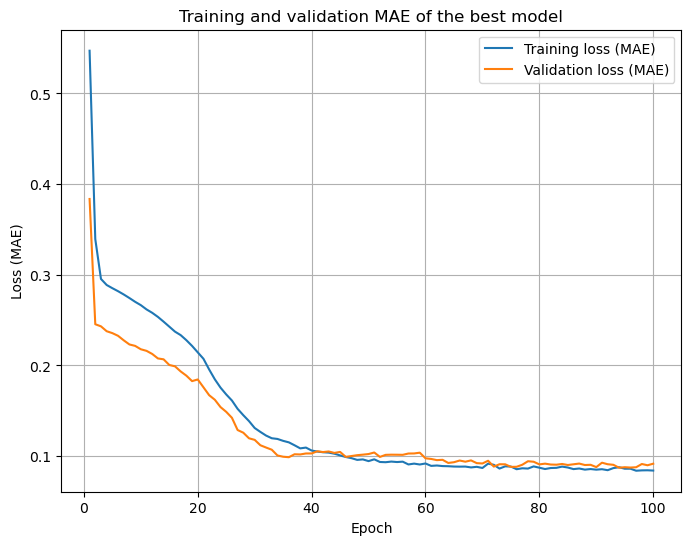

In [178]:
plt.figure(figsize=(8, 6))

epochs = np.arange(1, len(history.history['loss']) + 1)

plt.plot(epochs, history.history['loss'], label='Training loss (MAE)')
plt.plot(epochs, history.history['val_loss'], label='Validation loss (MAE)')

plt.xlabel('Epoch')
plt.ylabel('Loss (MAE)')
plt.title('Training and validation MAE of the best model')
plt.legend()
plt.grid(True)
plt.show()

### Predictions

Grid MSE against the noiseless target inside [-1.5,1.5] x [-1.5,1.5]: 0.002376300252310069


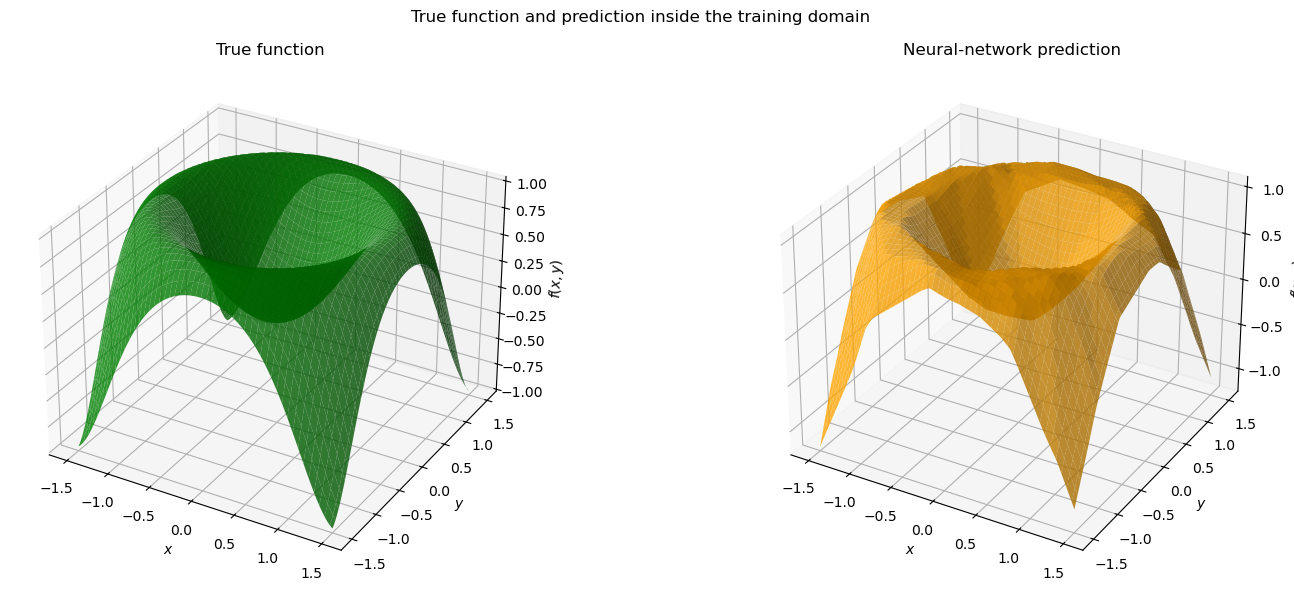

In [179]:
x_grid = np.linspace(-1.5, 1.5, 100)
y_grid = np.linspace(-1.5, 1.5, 100)

X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

grid_points = np.column_stack((
    X_grid.ravel(),
    Y_grid.ravel()
))

Z_true = f_2d(X_grid, Y_grid)
Z_pred = model.predict(grid_points, verbose=0).reshape(X_grid.shape)

grid_mse = np.mean((Z_pred - Z_true)**2)

print("Grid MSE against the noiseless target inside [-1.5,1.5] x [-1.5,1.5]:", grid_mse)

fig = plt.figure(figsize=(16, 6))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_grid, Y_grid, Z_true, alpha=0.8, color='green')
ax1.set_xlabel('$x$')
ax1.set_ylabel('$y$')
ax1.set_zlabel('$f(x,y)$')
ax1.set_title('True function')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_grid, Y_grid, Z_pred, alpha=0.8, color='orange')
ax2.set_xlabel('$x$')
ax2.set_ylabel('$y$')
ax2.set_zlabel('$f(x,y)$')
ax2.set_title('Neural-network prediction')

plt.suptitle('True function and prediction inside the training domain')
plt.tight_layout()
plt.show()

### Summary of the selected best model


In [180]:
print("Best model parameters:")
print("Number of hidden layers:", best_config["layers"])
print("Number of neurons per layer:", best_config["neurons"])
print("Activation function:", best_config["activation"])
print("Optimizer:", best_config["optimizer"])
print("Loss function:", best_config["loss"])
print("Validation metric:", best_config["metric"])
print("Number of trainable parameters:", best_config["n_parameters"])
print()


Best model parameters:
Number of hidden layers: 3
Number of neurons per layer: 20
Activation function: relu
Optimizer: adam
Loss function: mae
Validation metric: mse
Number of trainable parameters: 921



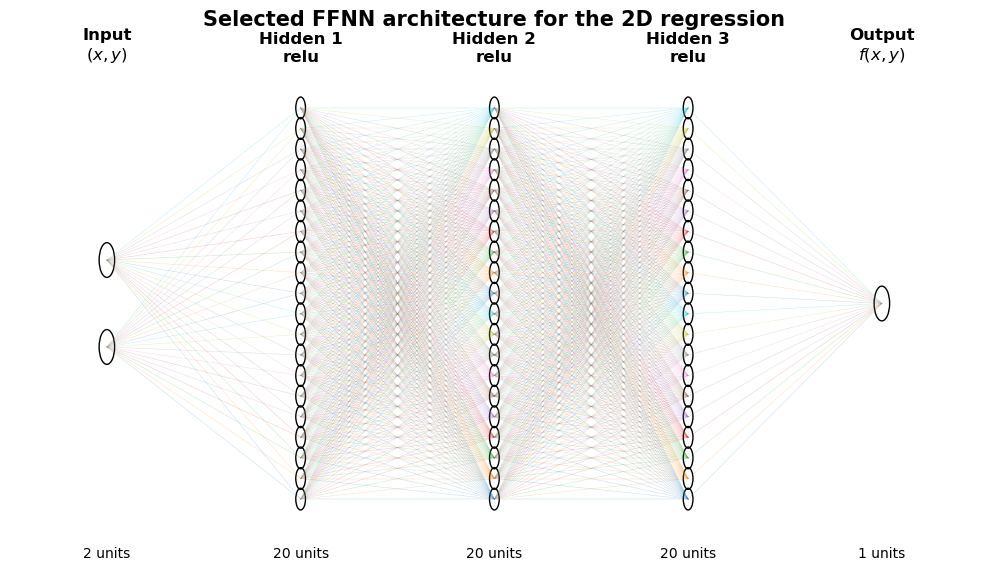

In [181]:
def draw_ffnn_architecture_2d(best_config):
    n_hidden_layers = int(best_config["layers"])
    n_neurons = int(best_config["neurons"])

    layer_sizes = [2] + [n_neurons] * n_hidden_layers + [1]
    layer_labels = (
        ["Input\n$(x,y)$"] +
        [f"Hidden {i+1}\n{best_config['activation']}" for i in range(n_hidden_layers)] +
        ["Output\n$f(x,y)$"]
    )

    x_positions = np.arange(len(layer_sizes))
    fig, ax = plt.subplots(figsize=(2.5 * len(layer_sizes), 7))

    y_positions_all = []

    for x, n_nodes, label in zip(x_positions, layer_sizes, layer_labels):
        y_positions = np.array([0.4, 0.6]) if n_nodes == 2 else (
            np.array([0.5]) if n_nodes == 1 else np.linspace(0.05, 0.95, n_nodes)
        )
        y_positions_all.append(y_positions)

        radius = 0.04 if n_nodes <= 2 else 0.025

        for y in y_positions:
            ax.add_patch(plt.Circle((x, y), radius, fill=False, linewidth=1.0))

        ax.text(x, 1.05, label, ha="center", va="bottom", fontsize=12, fontweight="bold")
        ax.text(x, -0.06, f"{n_nodes} units", ha="center", va="top", fontsize=10)

    for i in range(len(layer_sizes) - 1):
        alpha = 0.08 if layer_sizes[i] * layer_sizes[i+1] > 1000 else 0.25
        linewidth = 0.15 if layer_sizes[i] * layer_sizes[i+1] > 1000 else 0.35

        for y1 in y_positions_all[i]:
            for y2 in y_positions_all[i+1]:
                ax.plot(
                    [x_positions[i], x_positions[i+1]],
                    [y1, y2],
                    alpha=alpha,
                    linewidth=linewidth
                )

    ax.set_xlim(-0.5, len(layer_sizes) - 0.5)
    ax.set_ylim(-0.12, 1.12)
    ax.axis("off")

    plt.title("Selected FFNN architecture for the 2D regression", fontsize=15, fontweight="bold")
    plt.show()


draw_ffnn_architecture_2d(best_config)

The final model selected for Exercise 11.3 gives a good approximation of the function $f(x,y)=\sin(x^2+y^2)$ in the training domain. As in Exercise 11.2, the training and validation metrics are both low and close to each other, so the model is flexible enough to learn the nonlinear target without showing clear signs of overfitting.

Compared with the best model found for the cubic polynomial, the optimal architecture for the two-dimensional problem is more complex. This is reasonable because the input now has two variables and the target function has a richer structure than the one-dimensional polynomial. The comparison with the model inherited from Exercise 11.2 also supports this interpretation: the previous architecture already worked reasonably well, but the dedicated grid search for Exercise 11.3 finds a model better adapted to the new problem.

The main lesson is therefore the same as in Exercise 11.2: increasing the number of parameters can improve the fit, but the model must be selected using the validation metric, not only the training loss. A good architecture should be complex enough to represent the target function, but not unnecessarily complex to avoid overfitting and poor generalization ability.